# 实验一：图像基本操作与直方图

1. 对一幅图像进行 2 倍、4 倍、8 倍和 16 倍减采样，显示结果。
2. 显示一幅灰度图像 a，改变图像亮度使其整体变暗得到图像 b，显示两幅图像的直方图。
3. 对图像 b 进行直方图均衡化，显示结果图像和对应直方图。
4. 读入图像 c，执行直方图规定化，使图像 a 的灰度分布与 c 大致相同，显示变换后图像及对应直方图。

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

use_zh = True
if use_zh:
    plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

img_a_path = Path("img.png")
img_c_path = Path("img1.png")

a = np.array(Image.open(img_a_path).convert("L"))
c = np.array(Image.open(img_c_path).convert("L"))

print("图像 a 大小:", a.shape, "图像 c 大小:", c.shape)

def decimate(image_array: np.ndarray, factor: int) -> np.ndarray:
    return image_array[::factor, ::factor]


def darken_image(gray: np.ndarray, factor: float) -> np.ndarray:
    out = gray.astype(np.float32) * factor
    return np.clip(out, 0, 255).astype(np.uint8)


def equalize_histogram(gray: np.ndarray) -> np.ndarray:
    hist = np.bincount(gray.ravel(), minlength=256)
    cdf = hist.cumsum()
    nonzero = cdf > 0
    if not np.any(nonzero):
        return gray.copy()
    cdf_min = cdf[nonzero][0]
    total = gray.size
    if total == cdf_min:
        return gray.copy()
    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[gray]


def compute_cdf(gray: np.ndarray) -> np.ndarray:
    hist = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    cdf = hist.cumsum()
    if cdf[-1] == 0:
        return cdf
    return cdf / cdf[-1]


def build_specification_lut(cdf_src: np.ndarray, cdf_ref: np.ndarray) -> np.ndarray:
    lut = np.zeros(256, dtype=np.uint8)
    for src_level in range(256):
        target = cdf_src[src_level]
        idx = np.searchsorted(cdf_ref, target, side="left")
        if idx == 0:
            lut[src_level] = 0
        elif idx >= 256:
            lut[src_level] = 255
        else:
            prev_idx = idx - 1
            if abs(cdf_ref[prev_idx] - target) <= abs(cdf_ref[idx] - target):
                lut[src_level] = prev_idx
            else:
                lut[src_level] = idx
    return lut


def histogram_specification(src: np.ndarray, ref: np.ndarray) -> np.ndarray:
    cdf_src = compute_cdf(src)
    cdf_ref = compute_cdf(ref)
    lut = build_specification_lut(cdf_src, cdf_ref)
    return lut[src]

图像 a 大小: (300, 300) 图像 c 大小: (1440, 960)


## 任务 1：2/4/8/16 倍减采样并显示结果

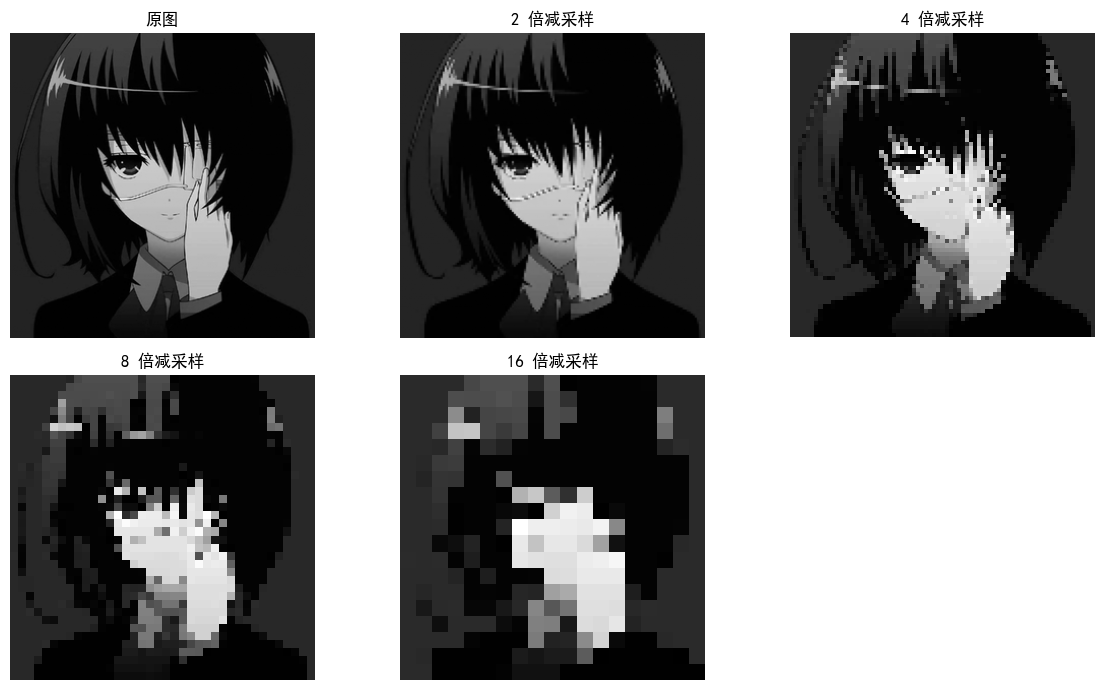

In [5]:
factors = [2, 4, 8, 16]
sampled_images = [decimate(a, f) for f in factors]

plt.figure(figsize=(12, 7))
plt.subplot(2, 3, 1)
plt.imshow(a, cmap="gray")
plt.title("原图" if use_zh else "Original")
plt.axis("off")

for i, (factor, sampled) in enumerate(zip(factors, sampled_images), start=2):
    plt.subplot(2, 3, i)
    plt.imshow(sampled, cmap="gray")
    plt.title(f"{factor} 倍减采样")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 任务 2：灰度图像 a 变暗得到 b，并显示 a、b 直方图

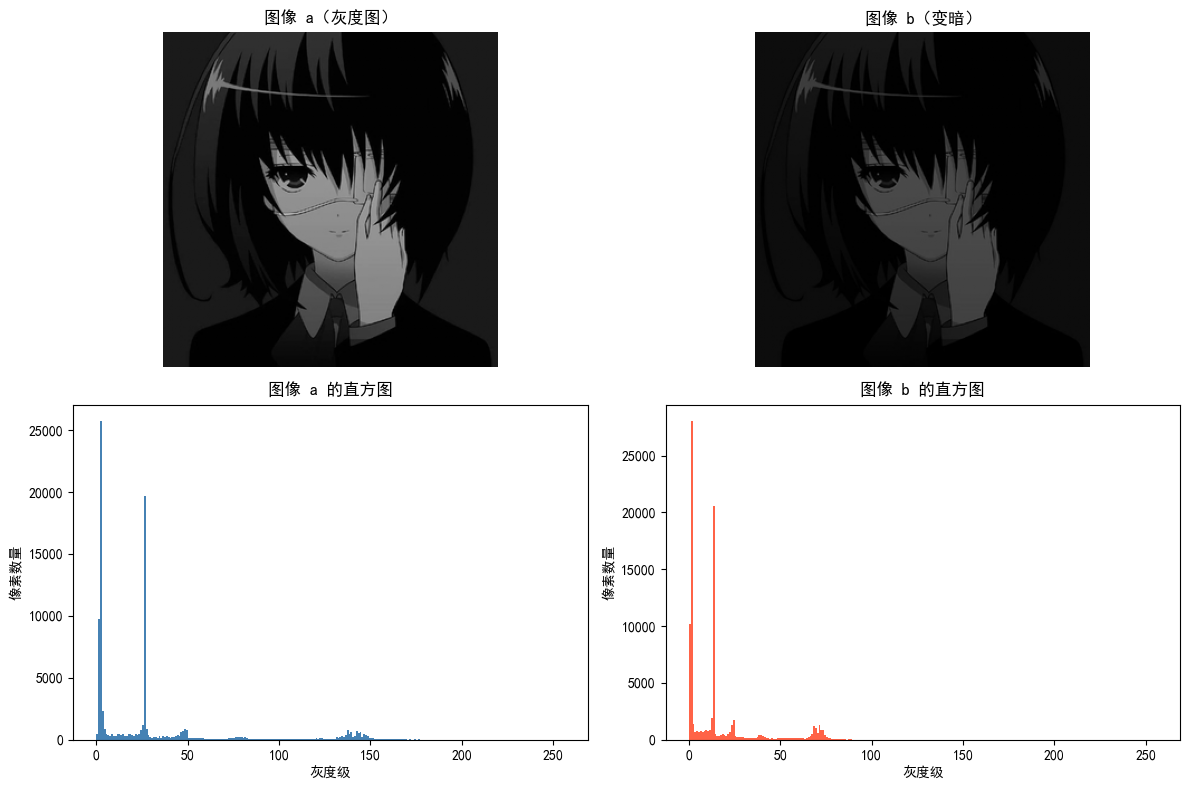

In [6]:
b = darken_image(a, 0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(a, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("图像 a（灰度图）")
axes[0, 0].axis("off")

axes[0, 1].imshow(b, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("图像 b（变暗）")
axes[0, 1].axis("off")

axes[1, 0].hist(a.ravel(), bins=256, range=(0, 256), color="steelblue")
axes[1, 0].set_title("图像 a 的直方图")
axes[1, 0].set_xlabel("灰度级")
axes[1, 0].set_ylabel("像素数量")

axes[1, 1].hist(b.ravel(), bins=256, range=(0, 256), color="tomato")
axes[1, 1].set_title("图像 b 的直方图")
axes[1, 1].set_xlabel("灰度级")
axes[1, 1].set_ylabel("像素数量")

plt.tight_layout()
plt.show()

## 任务 3：对图像 b 进行直方图均衡化

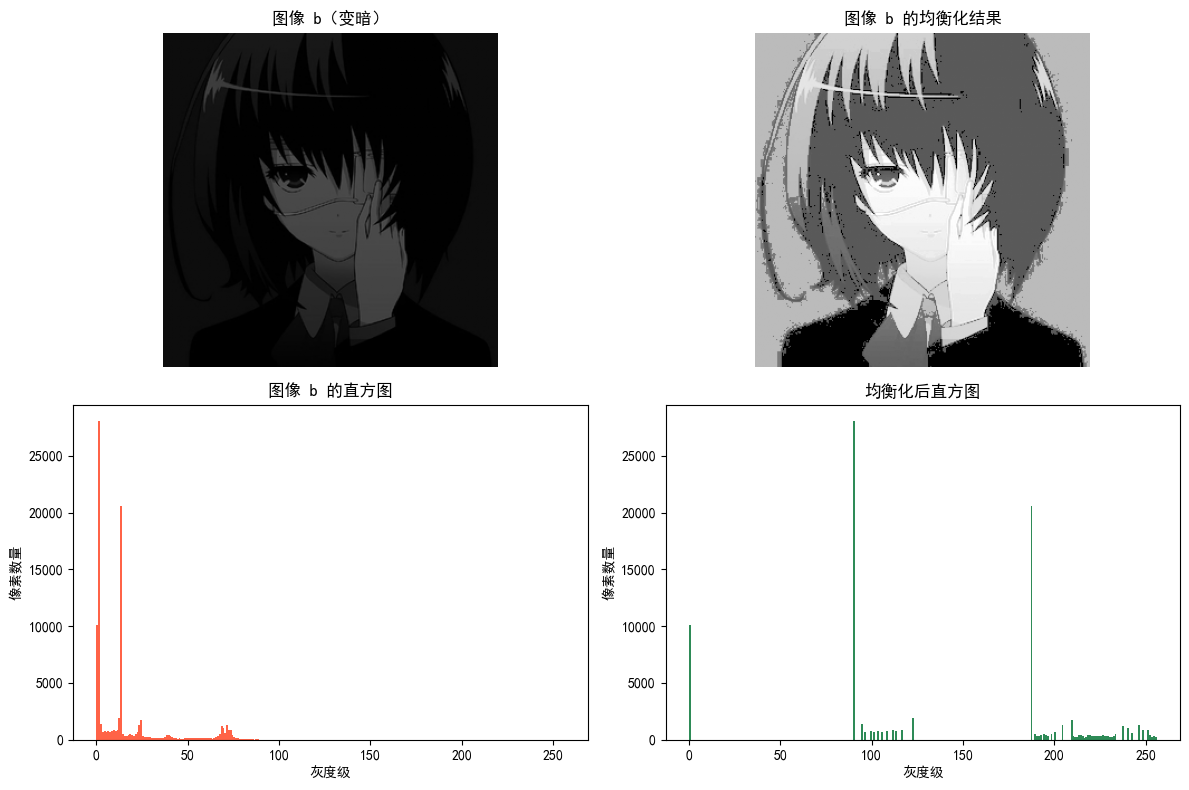

In [7]:
b_eq = equalize_histogram(b)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(b, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("图像 b（变暗）")
axes[0, 0].axis("off")

axes[0, 1].imshow(b_eq, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("图像 b 的均衡化结果")
axes[0, 1].axis("off")

axes[1, 0].hist(b.ravel(), bins=256, range=(0, 256), color="tomato")
axes[1, 0].set_title("图像 b 的直方图")
axes[1, 0].set_xlabel("灰度级")
axes[1, 0].set_ylabel("像素数量")

axes[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 256), color="seagreen")
axes[1, 1].set_title("均衡化后直方图")
axes[1, 1].set_xlabel("灰度级")
axes[1, 1].set_ylabel("像素数量")

plt.tight_layout()
plt.show()

## 任务 4：读入图像 c，对图像 a 做直方图规定化

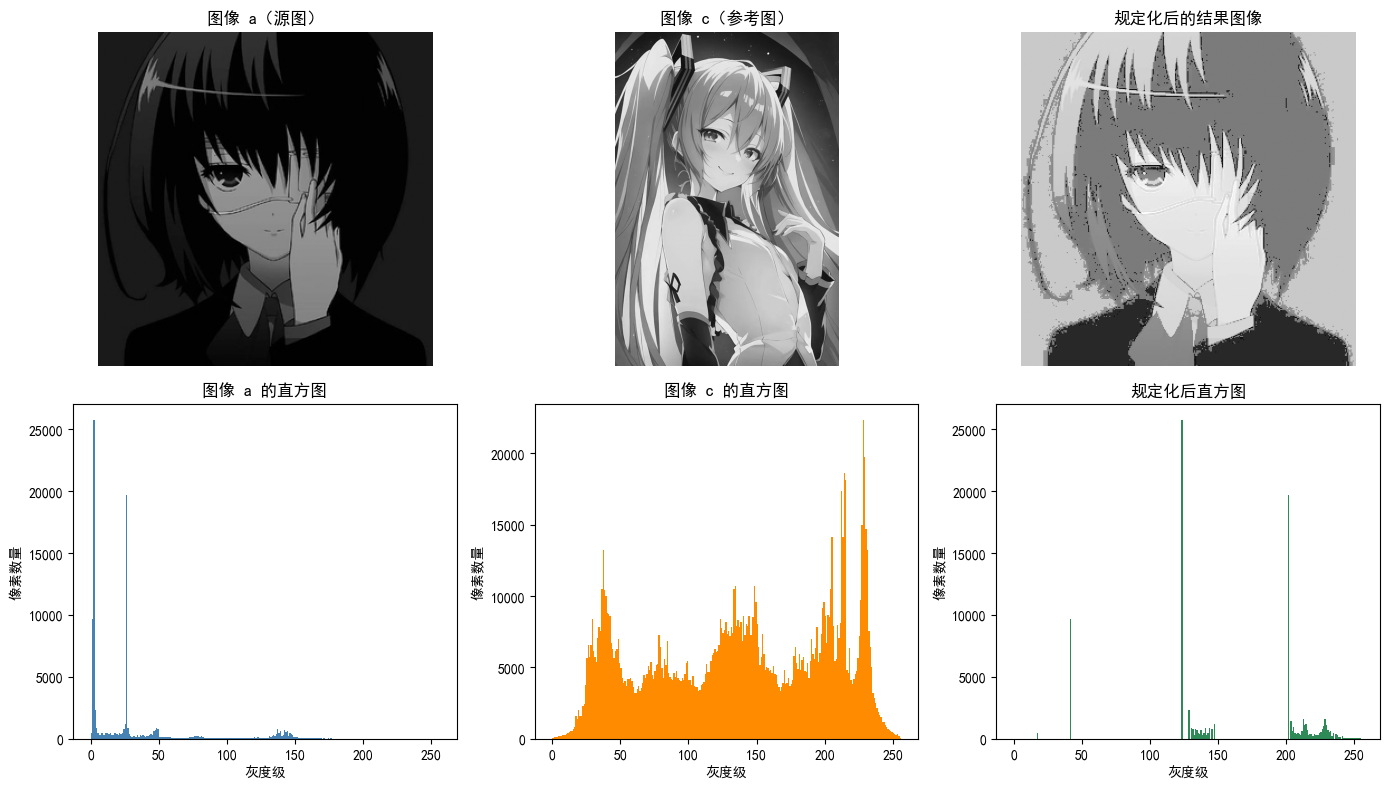

In [8]:
matched = histogram_specification(a, c)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(a, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("图像 a（源图）")
axes[0, 0].axis("off")

axes[0, 1].imshow(c, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("图像 c（参考图）")
axes[0, 1].axis("off")

axes[0, 2].imshow(matched, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("规定化后的结果图像")
axes[0, 2].axis("off")

axes[1, 0].hist(a.ravel(), bins=256, range=(0, 256), color="steelblue")
axes[1, 0].set_title("图像 a 的直方图")
axes[1, 0].set_xlabel("灰度级")
axes[1, 0].set_ylabel("像素数量")

axes[1, 1].hist(c.ravel(), bins=256, range=(0, 256), color="darkorange")
axes[1, 1].set_title("图像 c 的直方图")
axes[1, 1].set_xlabel("灰度级")
axes[1, 1].set_ylabel("像素数量")

axes[1, 2].hist(matched.ravel(), bins=256, range=(0, 256), color="seagreen")
axes[1, 2].set_title("规定化后直方图")
axes[1, 2].set_xlabel("灰度级")
axes[1, 2].set_ylabel("像素数量")

plt.tight_layout()
plt.show()